#  Group Term paper 1 
**Candidate number 67 and 129**
***

## 
**Importing**
***

In [251]:
import sys
print(sys.executable)

/opt/anaconda3/envs/FIE463/bin/python


In [252]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
from dataclasses import dataclass

## Part 1 - Euler equation errors
***

In [253]:
@dataclass
class Parameters:
        beta = 0.99**30
        gamma = 2.1
        tau = 0.3
        phi = 0.5
        alpha = 0.36
        delta = 1 - 0.94**30
        z = 1.0
        Nw = 0.8
        Nk = 0.2
        tau_a = 0.0
        tau_a_iid = 0.05
        pi_a = 0.57

par = Parameters()

In [254]:
def euler_err(K_next, K, par):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    """
    # Labor supply
    L = 0.5 * par.Nw

    # Interest rates from firm FOC, at time t and t+1
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Young capitalist's saving
    a = (2 * K_next) / par.Nk

    # Lump-sum tax on capitalists
    Ta = par.tau_a * (1 + r) * K
    Ta_next = par.tau_a * (1 + r_next) * K_next

    # Inheritance to young capitalists
    b = par.phi * (1 - par.tau_a) * (1 + r) * (2 * K /par.Nk)

    # Consumption of young and old capitalists
    cK_y = b + Ta - a
    cK_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a + Ta_next

    # Euler equation error
    LHS = cK_y**(-par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * cK_o**(-par.gamma)

    return LHS - RHS

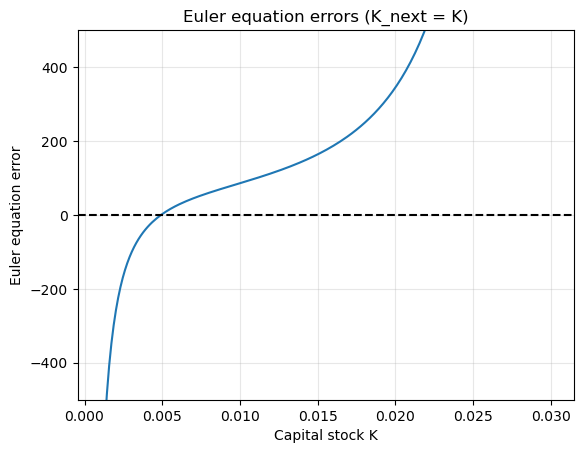

In [255]:
K_grid = np.linspace(0.001, 0.03, 200)
errors = [euler_err(K, K, par) for K in K_grid]

plt.figure()
plt.plot(K_grid, errors)
plt.grid(alpha = 0.3)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Capital stock K')
plt.ylabel('Euler equation error')
plt.title('Euler equation errors (K_next = K)')
plt.ylim(-500, 500)
plt.show()

The plot shows that the Euler equation error crosses zero around $K \approx 0.005$, confirming that the function has a root. We used 200 points in the interval \([0.001, 0.03]\) to show this.

## Part 2 - Steady state
***

In [256]:
@dataclass
class SteadyState:
    """Stores all steady-state quantities and prices"""
    pass

In [257]:
def compute_steady_state(par, euler_func = euler_err):
    
    K_ss = optimize.brentq(lambda K: euler_func(K, K, par), 0.001, 0.02)

    ss = SteadyState()
    ss.K = K_ss

    # Labor supply
    ss.L = 0.5 * par.Nw

    # Prices for capital and labor
    ss.r = par.alpha * par.z * ss.K**(par.alpha - 1) * ss.L**(1 - par.alpha) - par.delta
    ss.w = (1 - par.alpha) * par.z * ss.K**par.alpha * ss.L**(-par.alpha)

    # Lump sum tax on capital
    ss.Ta = par.tau_a * (1 + ss.r) * ss.K

    # Output
    ss.Y = par.z * ss.K**par.alpha * ss.L**(1 - par.alpha)

    # Capitalist variables
    ss.a = (2 * ss.K) / par.Nk
    ss.b = par.phi * (1 - par.tau_a) * (1 + ss.r) * ss.a
    ss.cK_y = ss.b + ss.Ta - ss.a
    ss.cK_o = (1 - par.phi) * (1 - par.tau_a) * (1 + ss.r) * ss.a + ss.Ta
    ss.s = ss.a / (ss.b + ss.Ta)

    # Worker variables
    ss.p = par.tau * ss.w
    ss.cW_y = (1 - par.tau) * ss.w + ss.Ta
    ss.cW_o = ss.p + ss.Ta

    # Goods market check - LHS - RHS should equal zero
    ss.goods_error = (ss.Y + (1 - par.delta) * ss.K - 0.5 * par.Nw * (ss.cW_y + ss.cW_o) - 0.5 * par.Nk * (ss.cK_y + ss.cK_o + ss.a))
    
    # Annualized interest rate over 30 years
    ss.r_annual = (1 + ss.r)**(1/30) - 1

    return ss

In [258]:
ss = compute_steady_state(par)

print("Steady-state equilibrium:")
print(f"  Output Y                = {ss.Y:.6f}")
print(f"  Capital K               = {ss.K:.6f}")
print(f"  Wage w                  = {ss.w:.6f}")
print(f"  Interest r              = {ss.r:.6f}")
print(f"  Bequest b               = {ss.b:.6f}")
print(f"  Savings a               = {ss.a:.6f}")
print(f"  c of worker(young)      = {ss.cW_y:.6f}")
print(f"  c of worker(old)        = {ss.cW_o:.6f}")
print(f"  c of capital(young)     = {ss.cK_y:.6f}")
print(f"  c of capital(old)       = {ss.cK_o:.6f}")
print(f"  Goods market error       = {ss.goods_error:.6f}")
print(f"  Annualized interest rate = {ss.r_annual*100:.6f}%")

Steady-state equilibrium:
  Output Y                = 0.082129
  Capital K               = 0.004922
  Wage w                  = 0.131407
  Interest r              = 5.162944
  Bequest b               = 0.151678
  Savings a               = 0.049223
  c of worker(young)      = 0.091985
  c of worker(old)        = 0.039422
  c of capital(young)     = 0.102456
  c of capital(old)       = 0.151678
  Goods market error       = 0.000000
  Annualized interest rate = 6.249348%


The model has a 30-year interest rate of 516%. To check if this rate is realistic, we annualize the rate over 30 years. The annualized net interest rate of 6.41% is a reasonable value, which suggests the model is calibrated correctly.

## Part 3 - Transition dynamics
***

In [259]:
class Simulation:
    """Stores simulated time series of all model variables."""
    pass

In [260]:
def simulate_olg(K0, T, par, euler_func=euler_err):
    """Simulate the OLG model for T periods"""

    sim = Simulation()

    sim.K = np.zeros(T + 1)
    sim.Y = np.zeros(T)
    sim.r = np.zeros(T)
    sim.w = np.zeros(T)
    sim.a = np.zeros(T)
    sim.b = np.zeros(T)
    sim.s = np.zeros(T)
    sim.cW_y = np.zeros(T)
    sim.cW_o = np.zeros(T)
    sim.cK_y = np.zeros(T)
    sim.cK_o = np.zeros(T)

    #Tax from part 4
    sim.Ta = np.zeros(T)

    # Labor supply
    L = 0.5 * par.Nw

    # Initial capital 
    sim.K[0] = K0

    # Loop over all periods
    for t in range(T):
        K = sim.K[t]

        # Prices
        sim.r[t] = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
        sim.w[t] = (1 - par.alpha) * par.z * K**par.alpha * L**(-par.alpha)
        sim.Y[t] = par.z * K**par.alpha * L**(1 - par.alpha)
        sim.Ta[t] = par.tau_a * (1 + sim.r[t]) * sim.K[t]

        # Capitalist variables
        sim.b[t] = par.phi * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk)

        # Find next period capital using root-finder
        if t < T - 1:
            K_upper = (sim.b[t] + sim.Ta[t]) * par.Nk / 2 * 0.99 #Max amount that can be saved, avoiding negative consumption
            K_next = optimize.brentq(lambda Kn: euler_func(Kn, K, par), 0.0001, K_upper)
            sim.K[t + 1] = K_next
        else:
            sim.K[t + 1] = sim.K[t]

        # Capitalist savings and consumption
        sim.a[t] = 2 * sim.K[t + 1] / par.Nk
        sim.cK_y[t] = sim.b[t] + sim.Ta[t] - sim.a[t]
        sim.cK_o[t] = (1 - par.phi) * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk) + sim.Ta[t]
        sim.s[t] = sim.a[t] / (sim.b[t] + sim.Ta[t])

        # Worker consumption
        sim.cW_y[t] = (1 - par.tau) * sim.w[t] + sim.Ta[t]
        sim.cW_o[t] = par.tau * sim.w[t] + sim.Ta[t]

        # Goods market clearing
        demand = (0.5 * par.Nw * (sim.cW_y[t] + sim.cW_o[t]) + 0.5 * par.Nk * (sim.cK_y[t] + sim.cK_o[t] + sim.a[t]))
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]

        assert abs(demand - supply) < 1e-8 # Returns error if goods market does not clear

    return sim

In [261]:
# Simulate 20 periods, starting with 0.5 times the steady-state capital
sim = simulate_olg(ss.K / 2, 20, par)

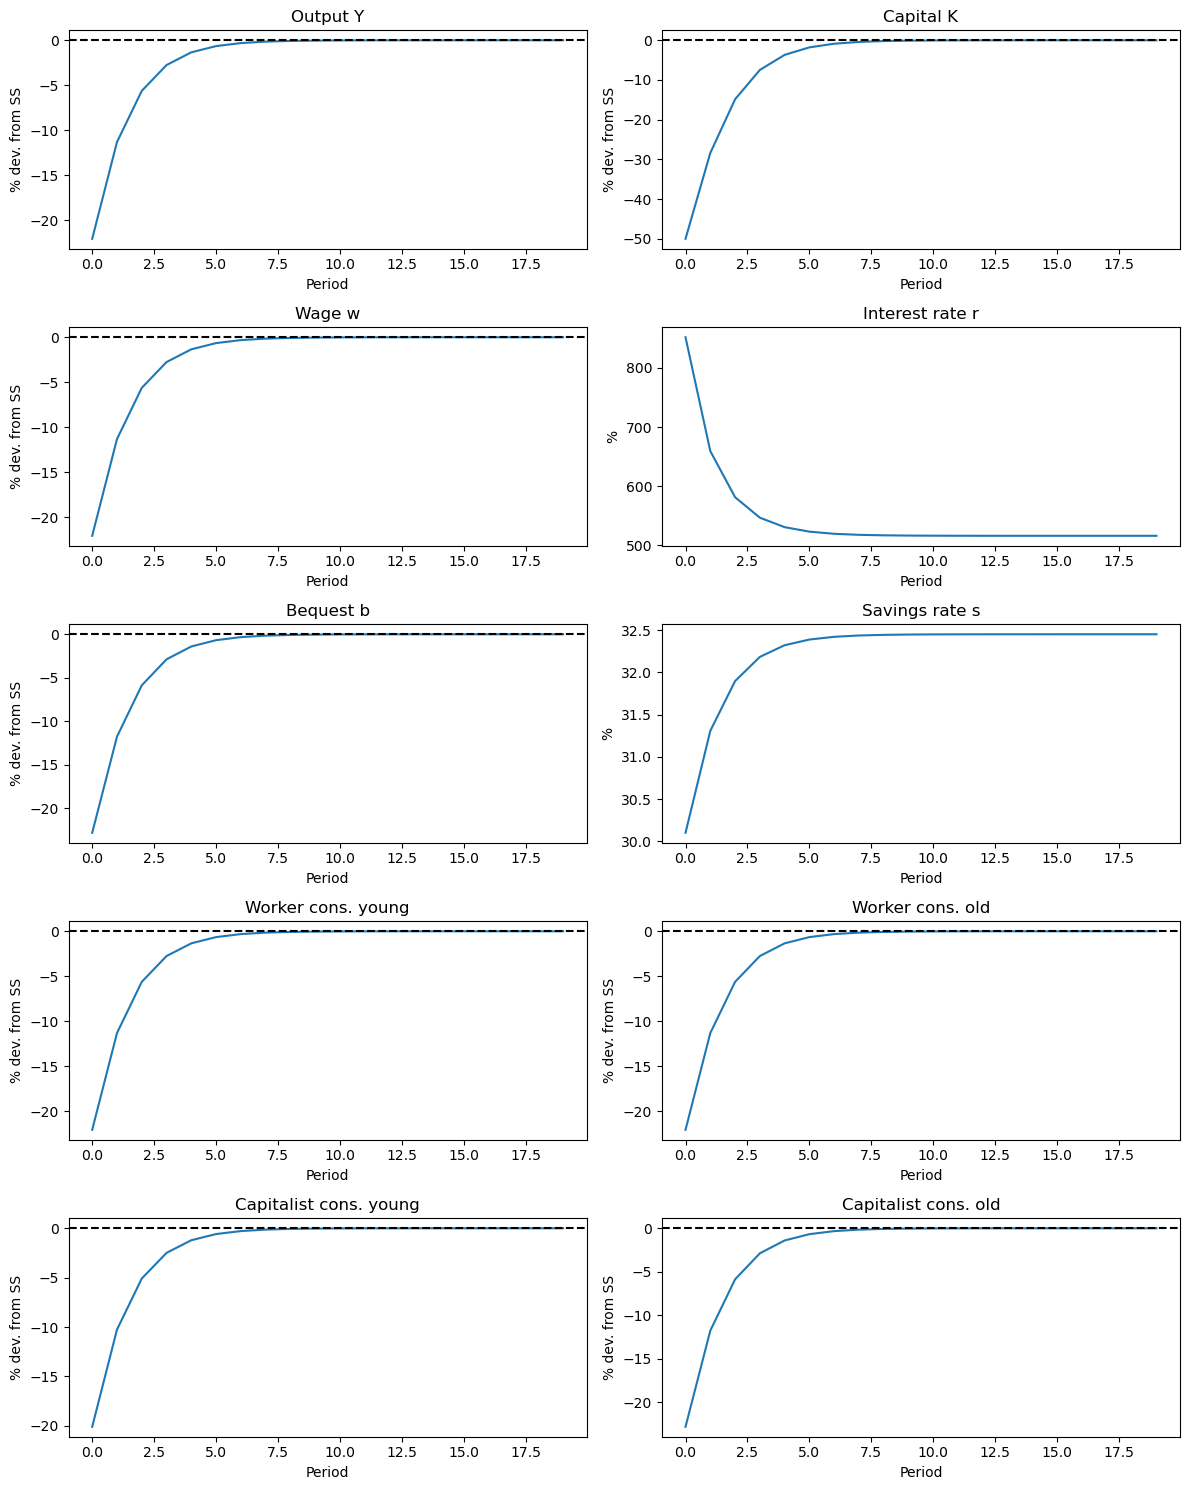

In [262]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

# Variables as percent deviation from steady state
pct_vars = [
    (sim.Y, ss.Y, 'Output Y'),
    (sim.K[:-1], ss.K, 'Capital K'), # As sim.K has T+1 elements, we index it to T-1
    (sim.w, ss.w, 'Wage w'),
    (sim.r, None, 'Interest rate r'),
    (sim.b, ss.b, 'Bequest b'),
    (sim.s, None, 'Savings rate s'),
    (sim.cW_y, ss.cW_y, 'Worker cons. young'),
    (sim.cW_o, ss.cW_o, 'Worker cons. old'),
    (sim.cK_y, ss.cK_y, 'Capitalist cons. young'),
    (sim.cK_o, ss.cK_o, 'Capitalist cons. old'),
]

for i, (series, ss_val, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]

    #If no steady state
    if ss_val is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')

    #If steady state
    else:
        ax.plot(100 * (series - ss_val) / ss_val)
        ax.axhline(0, color='black', linestyle='--')
        ax.set_ylabel('% dev. from SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

The economy converges to the steady state, confirming that the steady state computed in part 2 is correct. 

## Part 4 - Introduction of a wealth tax
***

In [263]:
# Save old steady state
ss_old = ss

# Set wealth tax rate
par.tau_a = 0.05

# New steady state
ss_new = compute_steady_state(par)

print("New steady state with wealth tax:")
print(f"   Output Y                = {ss_new.Y:.6f}")
print(f"   Capital K               = {ss_new.K:.6f}")
print(f"   Wage w                  = {ss_new.w:.6f}")
print(f"   Interest r              = {ss_new.r:.6f}")
print(f"   Savings rate            = {ss_new.s*100:.2f}%")
print(f"   Tax                     = {ss_new.Ta:.6f}")
print(f"   c of worker(young)      = {ss_new.cW_y:.6f}")
print(f"   c of worker(old)        = {ss_new.cW_o:.6f}")
print(f"   c of capital(young)     = {ss_new.cK_y:.6f}")
print(f"   c of capital(old)       = {ss_new.cK_o:.6f}")

print(f"\nChange in capital: {100*(ss_new.K - ss_old.K)/ss_old.K:.2f}%")
print(f"Change in savings rate: {100*(ss_new.s - ss_old.s):.2f} pp")

New steady state with wealth tax:
   Output Y                = 0.079977
   Capital K               = 0.004572
   Wage w                  = 0.127963
   Interest r              = 5.453349
   Savings rate            = 32.28%
   Tax                     = 0.001475
   c of worker(young)      = 0.091049
   c of worker(old)        = 0.039864
   c of capital(young)     = 0.095907
   c of capital(old)       = 0.141629

Change in capital: -7.11%
Change in savings rate: -0.17 pp


The wealth tax reduces the capital stock by 7.11% and the savings rate by 0.17 percentage points. This is because the tax lowers the return on savings for capitalists, so they save less. 

In [264]:
sim2 = simulate_olg(ss_old.K, 20, par)

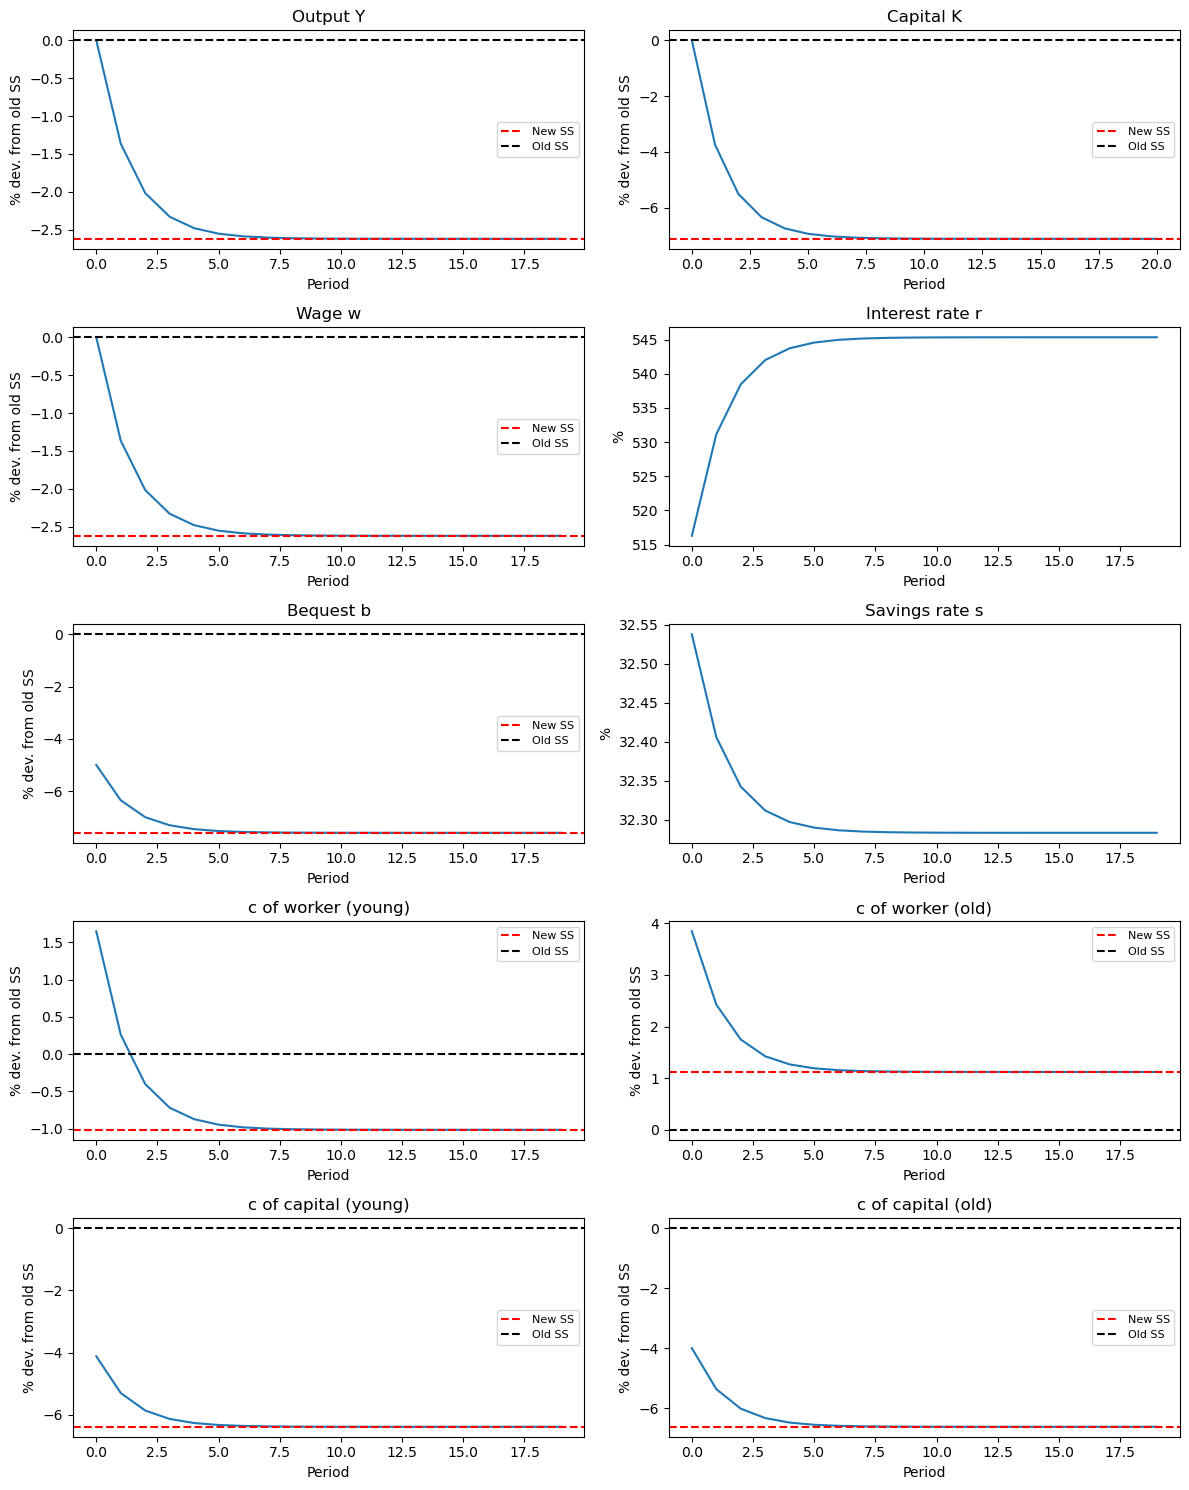

In [265]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim2.Y, ss_old.Y, ss_new.Y, 'Output Y'),
    (sim2.K, ss_old.K, ss_new.K, 'Capital K'),
    (sim2.w, ss_old.w, ss_new.w, 'Wage w'),
    (sim2.r, None, None, 'Interest rate r'),
    (sim2.b, ss_old.b, ss_new.b, 'Bequest b'),
    (sim2.s, None, None, 'Savings rate s'),
    (sim2.cW_y, ss_old.cW_y, ss_new.cW_y, 'c of worker (young)'),
    (sim2.cW_o, ss_old.cW_o, ss_new.cW_o, 'c of worker (old)'),
    (sim2.cK_y, ss_old.cK_y, ss_new.cK_y, 'c of capital (young)'),
    (sim2.cK_o, ss_old.cK_o, ss_new.cK_o, 'c of capital (old)'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if old is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

Workers are initially better off due to the transfer from the wealht tax, but worse off in the new steady state as lower capital reduces wages. Old workers benefit since the transfer more than offsets the wage decline. Capitalists are worse of both along the transition and in the new steady state as the tax directly reduces their wealth and consumption. 

## Part 5 - Social welfare and the optimal wealth tax
***

In [266]:
def crra_utility(c, gamma):
    """CRRA utility function."""
    if gamma == 1:
        return np.log(c)
    else:
        return c**(1 - gamma) / (1 - gamma)

In [267]:
def social_welfare(ss, par):
    """Compute utilitarian social welfare in steady state."""

    # Young worker: u(cW_y) + beta * u(cW_o)
    uW_y = crra_utility(ss.cW_y, par.gamma) + par.beta * crra_utility(ss.cW_o, par.gamma)
    # Old worker: u(cW_o)
    uW_o = crra_utility(ss.cW_o, par.gamma)
    # Young capitalist: u(cK_y) + beta * u(cK_o)

    uK_y = crra_utility(ss.cK_y, par.gamma) + par.beta * crra_utility(ss.cK_o, par.gamma)
    # Old capitalist: u(cK_o)
    uK_o = crra_utility(ss.cK_o, par.gamma)

    SW = 0.5 * par.Nw * (uW_y + uW_o) + 0.5 * par.Nk * (uK_y + uK_o)
    return SW

In [268]:
# Welfare without wealth tax
par.tau_a = 0.0
ss_no_tax = compute_steady_state(par)
SW_no_tax = social_welfare(ss_no_tax, par)

# Welfare with wealth tax
par.tau_a = 0.05
ss_with_tax = compute_steady_state(par)
SW_with_tax = social_welfare(ss_with_tax, par)

print(f"Social welfare without wealth tax: {SW_no_tax:.6f}")
print(f"Social welfare with wealth tax:    {SW_with_tax:.6f}")

if SW_with_tax > SW_no_tax:
    print("Households prefer the steady state with the wealth tax.")
else:
    print("Households prefer the steady state without the wealth tax.")

Social welfare without wealth tax: -29.565242
Social welfare with wealth tax:    -29.534233
Households prefer the steady state with the wealth tax.


Old workers benefit from the wealth tax transfer, while young workers are slightly worse off due to lower wages. Capitalists are worse off. Since workers make up to 80% of the population and the utility gains from redistribution outweight the lossess, welfare is higher with the wealth tax. 

In [269]:
def neg_welfare(tau_a):
    """Negative social welfare function of tau_a (for minimization)."""
    par.tau_a = tau_a
    try:
        ss_temp = compute_steady_state(par)
        return -social_welfare(ss_temp, par)
    except:
        return 0.0

result = optimize.minimize_scalar(neg_welfare, bounds=(0.001, 0.3), method='bounded')
tau_a_opt = result.x

print(f"Optimal wealth tax rate: {tau_a_opt*100:.2f}%")

Optimal wealth tax rate: 4.06%


In [270]:
par.tau_a = tau_a_opt
ss_opt = compute_steady_state(par)

print(f"Change in output Y: {100*(ss_opt.Y - ss_no_tax.Y)/ss_no_tax.Y:.2f}%")
print(f"Change in capital K: {100*(ss_opt.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Change in output Y: -2.12%
Change in capital K: -5.78%


Even though output and capital are lower, welfare is higher because the wealth tax redistributes resources from capitalists to workers. Since workers have lower consumption, the utility gain for workers outweights the utility loss for capitalists.

## Part 6 - Uncertainty about wealth taxes
***

In [271]:
def euler_err_uncertain(K_next, K, par):
    """
    Euler equation error with uncertainty about next period's wealth tax.
    """
    L = 0.5 * par.Nw

    # Interest rates
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Current period (uses the actual tax rate)
    Ta = par.tau_a * (1 + r) * K
    a = 2 * K_next / par.Nk
    b = par.phi * (1 - par.tau_a) * (1 + r) * (2 * K / par.Nk)

    # LHS
    LHS = (b + Ta - a)**(-par.gamma)

    # Expected RHS over two states
    # State 1: no tax next period (prob 1 - pi_a)
    c_old_no_tax = (1 - par.phi) * (1 + r_next) * a
    term_no_tax = 1.0 * c_old_no_tax**(-par.gamma)

    # State 2: wealth tax next period (prob pi_a)
    Ta_next_tax = par.tau_a_iid * (1 + r_next) * K_next
    c_old_tax = (1 - par.phi) * (1 - par.tau_a_iid) * (1 + r_next) * a + Ta_next_tax
    term_tax = (1 - par.tau_a_iid) * c_old_tax**(-par.gamma)

    E_RHS = (1 - par.pi_a) * term_no_tax + par.pi_a * term_tax

    RHS = par.beta * (1 + r_next) * (1 - par.phi) * E_RHS

    return LHS - RHS

In [272]:
par.tau_a = 0.0
ss_uncertain = compute_steady_state(par, euler_func=euler_err_uncertain)

print("Steady state with uncertainty (actual tau_a = 0):")
print(f"  Capital K    = {ss_uncertain.K:.6f}")
print(f"  Output Y     = {ss_uncertain.Y:.6f}")
print(f"  Savings rate = {ss_uncertain.s*100:.2f}%")
print(f"\nOriginal SS capital (Part 2): {ss_no_tax.K:.6f}")
print(f"Difference: {100*(ss_uncertain.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Steady state with uncertainty (actual tau_a = 0):
  Capital K    = 0.005000
  Output Y     = 0.082595
  Savings rate = 32.77%

Original SS capital (Part 2): 0.004922
Difference: 1.58%


This steady state is different from part 2 because capitalists now face uncertainty about future taxes. Even though the actual tax is always zero, the risk of a future wealth taxc causes them to save more as a precaution which increases the capital stock

In [273]:
sim6 = simulate_olg(ss_no_tax.K, 20, par, euler_func=euler_err_uncertain)

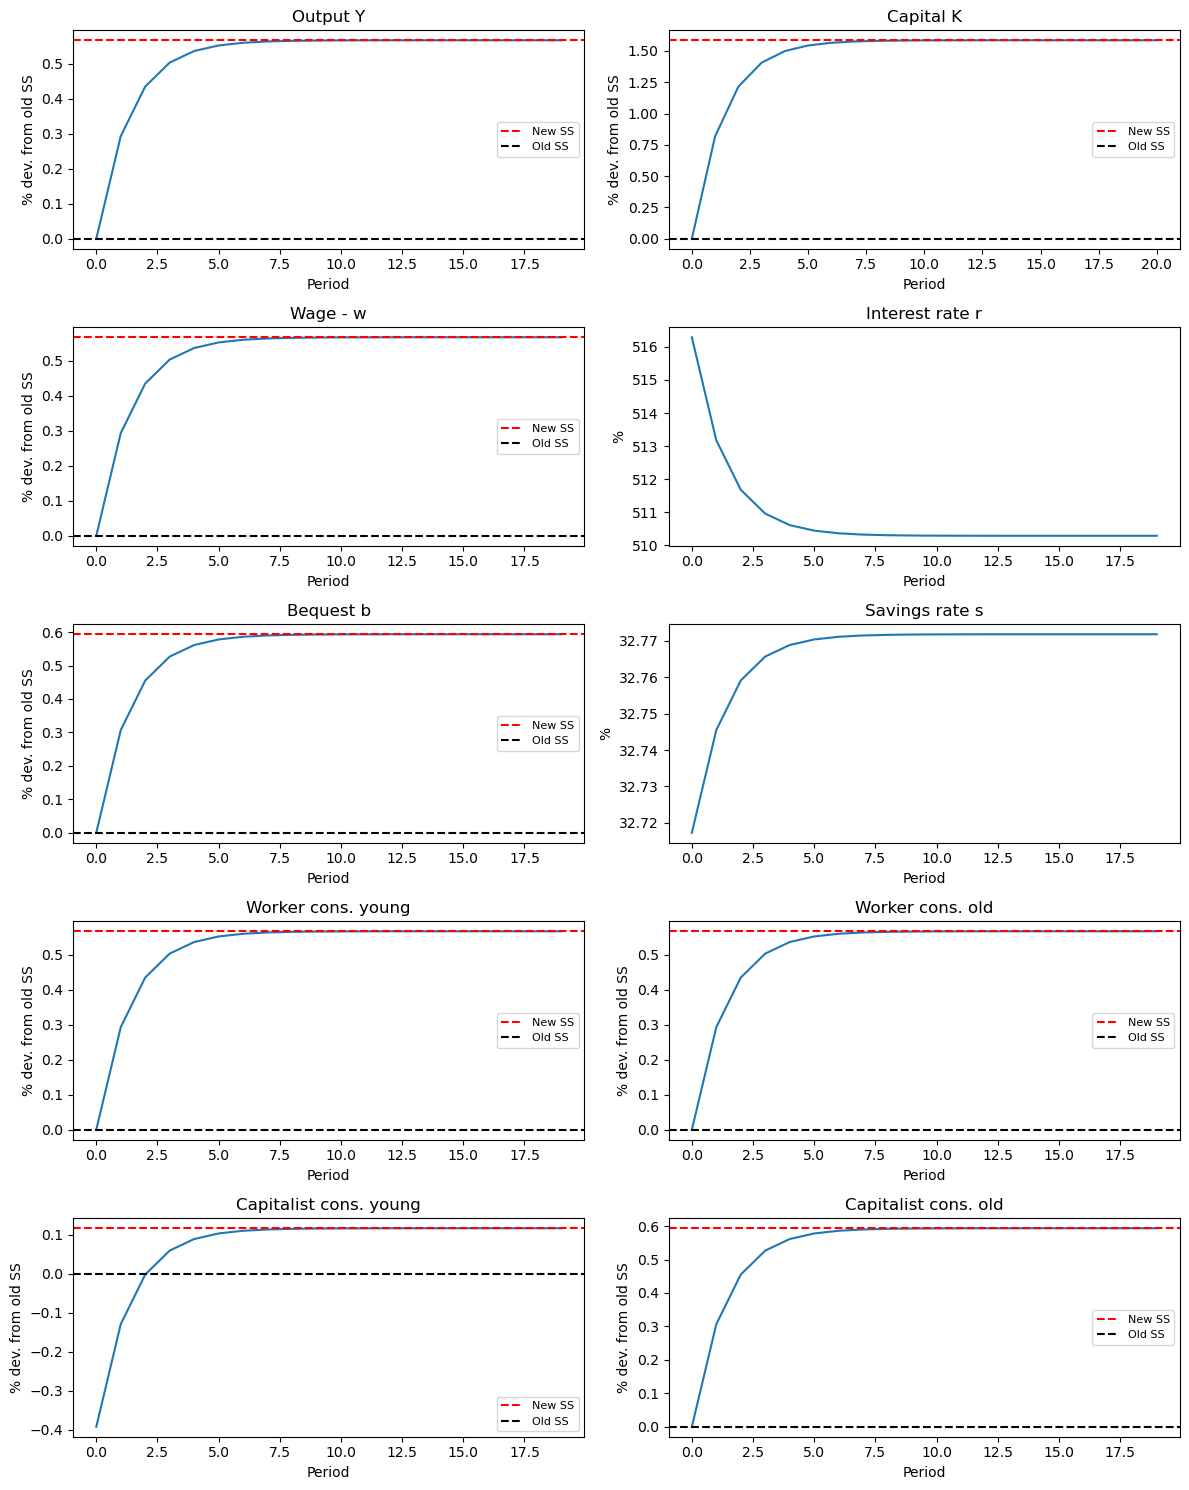

In [276]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim6.Y, ss_no_tax.Y, ss_uncertain.Y, 'Output Y'),

    (sim6.K, ss_no_tax.K, ss_uncertain.K, 'Capital K'),
    (sim6.w, ss_no_tax.w, ss_uncertain.w, 'Wage - w'),
    (sim6.r, None, None, 'Interest rate r'),
    (sim6.b, ss_no_tax.b, ss_uncertain.b, 'Bequest b'),
    (sim6.s, None, None, 'Savings rate s'),
    (sim6.cW_y, ss_no_tax.cW_y, ss_uncertain.cW_y, 'Worker cons. young'),
    (sim6.cW_o, ss_no_tax.cW_o, ss_uncertain.cW_o, 'Worker cons. old'),
    (sim6.cK_y, ss_no_tax.cK_y, ss_uncertain.cK_y, 'Capitalist cons. young'),
    (sim6.cK_o, ss_no_tax.cK_o, ss_uncertain.cK_o, 'Capitalist cons. old'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if old is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

Comapred to part 2, the capital stock is higher due to to precautionary savings. Compared to part 5, the effect is smaller since the tax is never actually applied, The key is that uncertainty alone changes behaviour even without the tax being implemented. 